In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Lire le fichier (CSV recommandé)
data = pd.read_csv('Data1.csv')

data



,YearsExperience,Salary,age
0,1.1,39343.0,33
1,1.3,46205.0,34
2,1.5,37731.0,35
3,2.0,43525.0,36
4,2.2,39891.0,37
5,2.9,56642.0,38
6,3.0,60150.0,39
7,3.2,54445.0,40
8,3.2,64445.0,41
9,3.7,57189.0,42


In [2]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
 2   age              30 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None


In [4]:
#  Variables multiples

X = data[['YearsExperience', 'age']].values
y = data['Salary'].values

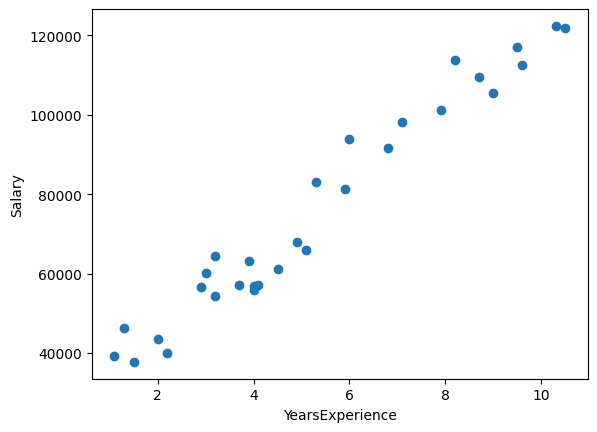

In [5]:
#  Visualisation (optionnel)
plt.scatter(data['YearsExperience'], y)
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

In [6]:

#  Ajouter le biais (colonne de 1)
X_b = np.hstack((np.ones((X.shape[0], 1)), X))  # [1, x1, x2]

In [7]:
#  Séparer train / test (manuellement)
np.random.seed(0)
indices = np.arange(X_b.shape[0])
np.random.shuffle(indices)

train_size = int(2/3 * len(indices))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X_b[train_idx]
X_test  = X_b[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

In [8]:

# Calcul des coefficients (formule normale)
# θ = (X^T X)^(-1) X^T y
theta = np.linalg.inv(X_train.T.dot(X_train)).dot(X_train.T).dot(y_train)

print("Theta :", theta)
print("Intercept :", theta[0])
print("Coefficients :", theta[1:])

Theta : [67278.66284349 13301.26876488 -1304.79398853]
Intercept : 67278.6628434888
Coefficients : [13301.26876488 -1304.79398853]


In [9]:

#  Prédictions
y_pred = X_test.dot(theta)

In [10]:

#  Métriques FROM SCRATCH
MAE = np.mean(np.abs(y_test - y_pred))
MSE = np.mean((y_test - y_pred)**2)
RMSE = np.sqrt(MSE)
R2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - np.mean(y_test))**2)

print("MAE :", MAE)
print("MSE :", MSE)
print("RMSE :", RMSE)
print("R² :", R2)

MAE : 4788.010131790701
MSE : 37179023.484684005
RMSE : 6097.460412719709
R² : 0.9254735610261925


In [11]:
#  Prédiction sur nouvelles données
# format : [YearsExperience, Age]
NewData = np.array([[5, 30], [4, 25]])

In [12]:
# Ajouter biais
NewData_b = np.hstack((np.ones((NewData.shape[0], 1)), NewData))

y_new = NewData_b.dot(theta)
print("Nouvelles prédictions :", y_new)

Nouvelles prédictions : [94641.18701203 87863.88818979]
